In [1]:
import corner 
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
chain_files = glob.glob("./chains_export/*.h5")
print("Found {} chain files.".format(len(chain_files)))

Found 28 chain files.


Parameters: ['h0', 'om', 'w0', 'wa', 'lambda_mst', 'lambda_mst_sigma', 'alpha_lambda', 'gamma_pl_0', 'gamma_pl_1', 'gamma_pl_2', 'gamma_pl_3', 'gamma_pl_4', 'gamma_pl_5', 'gamma_pl_6', 'gamma_pl_7', 'gamma_pl_8', 'gamma_pl_9', 'gamma_pl_10', 'gamma_pl_11', 'a_ani', 'a_ani_sigma']
Description: MCMC chain. 
samples: array of shape (n_samples, n_parameters). 
parameters: list of parameter names. 
Cosmological model: Uw_0w_aCDM. 
Lenses: RXJ1131-1231, SDSSJ0029-0055, SDSSJ0037-0942, SDSSJ1112+0826, SDSSJ1204+0358, SDSSJ1250+0523, SDSSJ1306+0600, SDSSJ1402+6321, SDSSJ1531-0105, SDSSJ1621+3931, SDSSJ1627-0053, SDSSJ1630+4520. 
Dataset: TDCOSMO+ SLACS + SL2S. 
Parameter description (see Table 3 of TDCOSMO2025): 
 - h0: Hubble constant in units of km/s/Mpc 
 - om: Matter density parameter 
 - w0: Present-day value of the dark energy equation of state parameter 
 - wa: Evolution rate of the dark energy equation of state parameter 
 - lambda_mst: Internal MST population mean 
 - lambda_mst_sigma

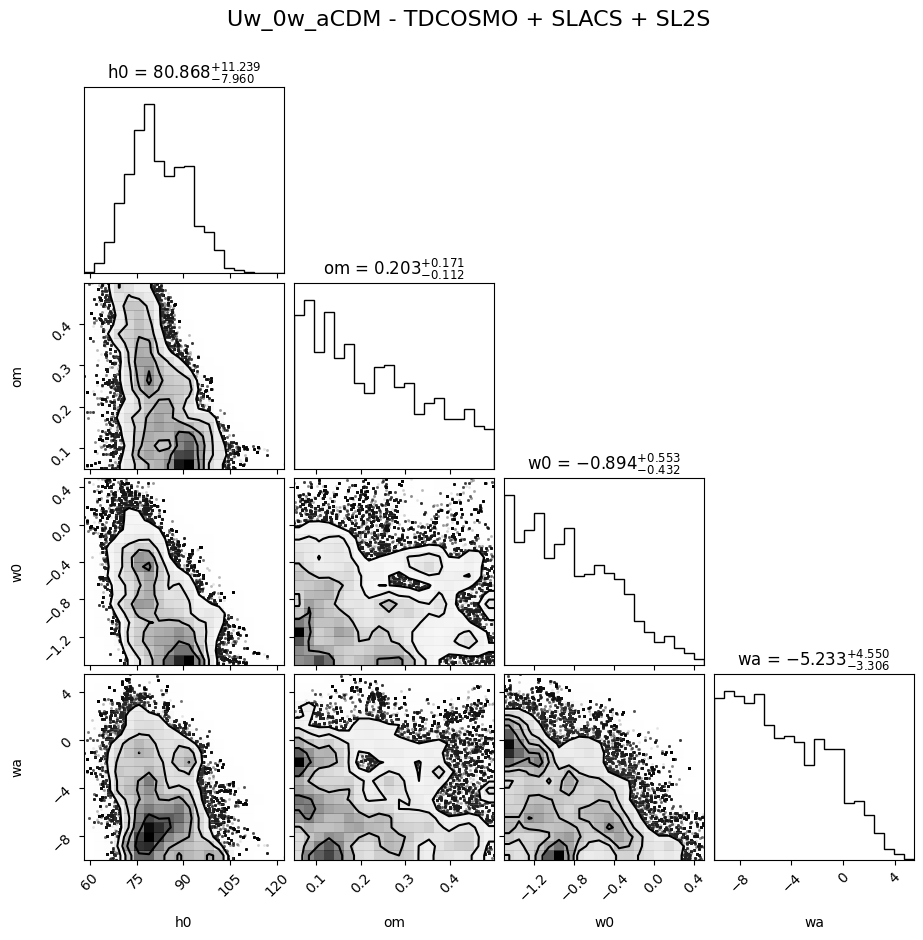

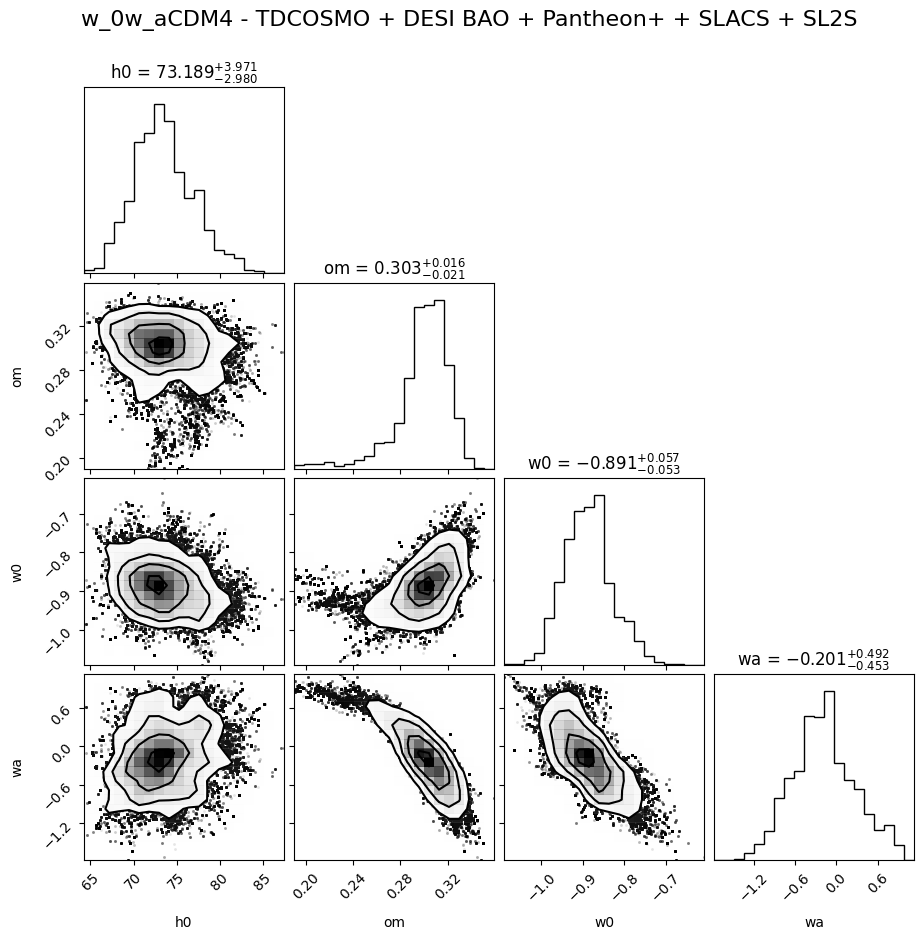

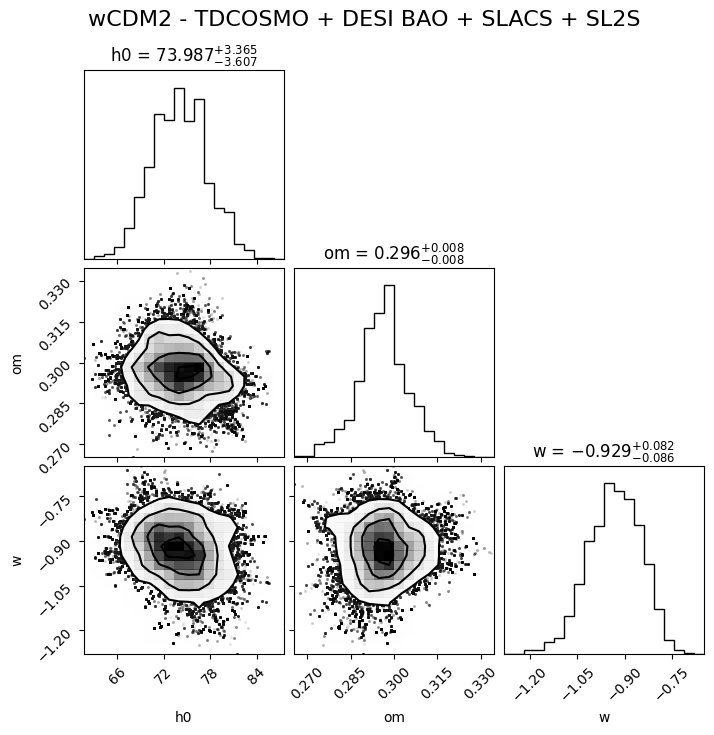

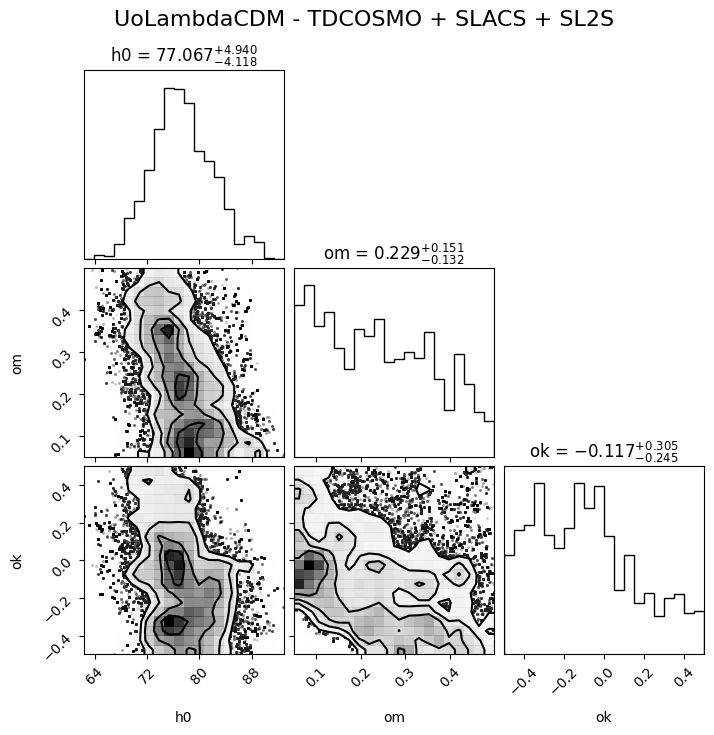

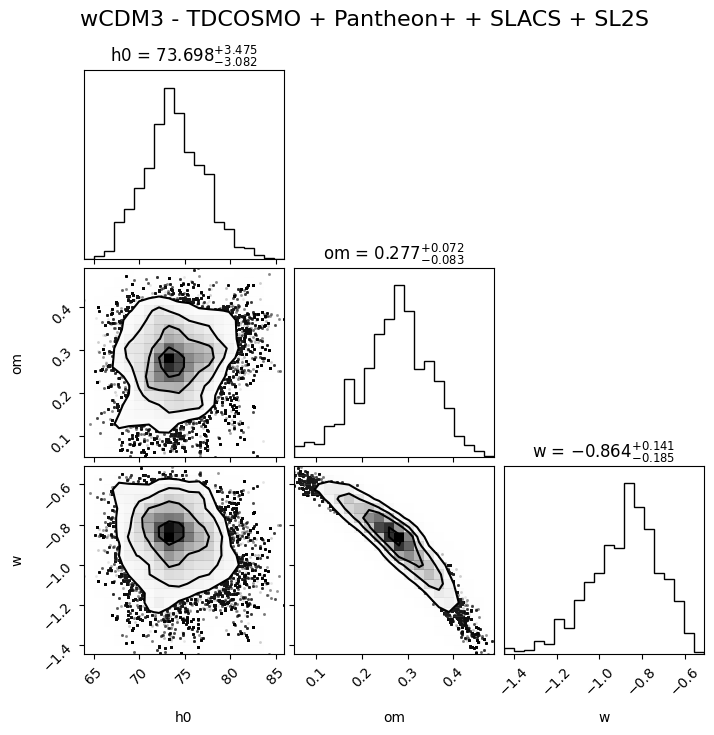

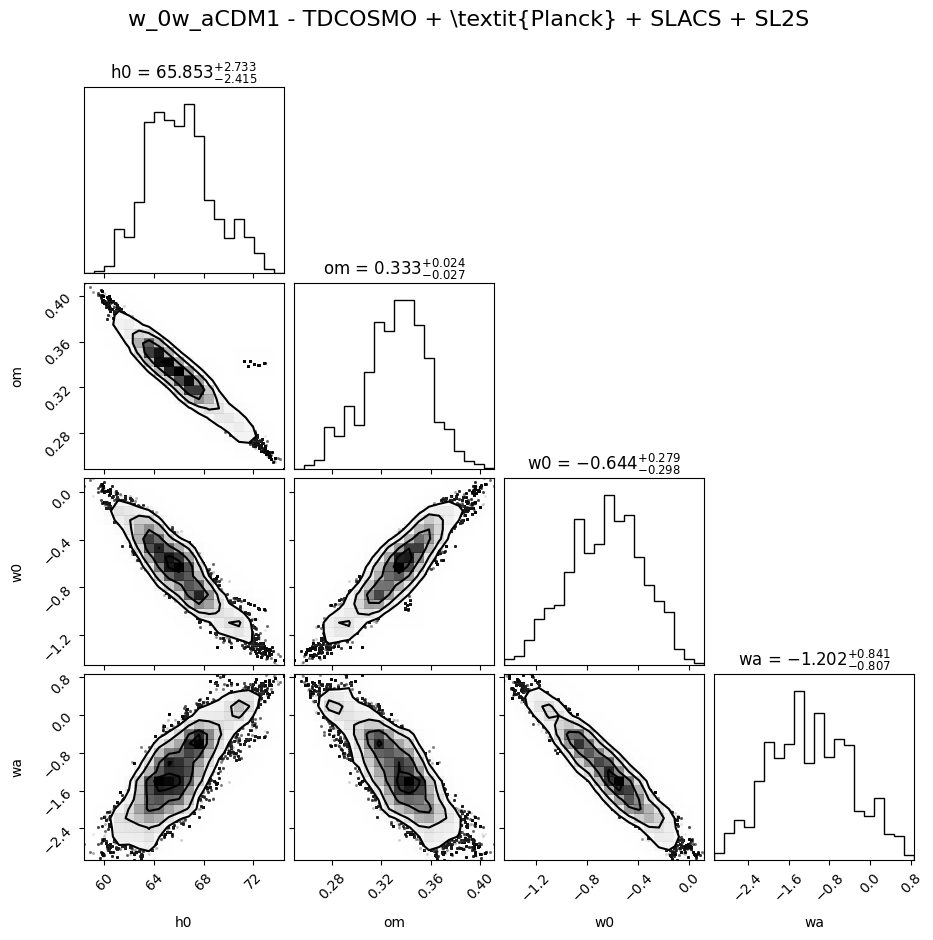

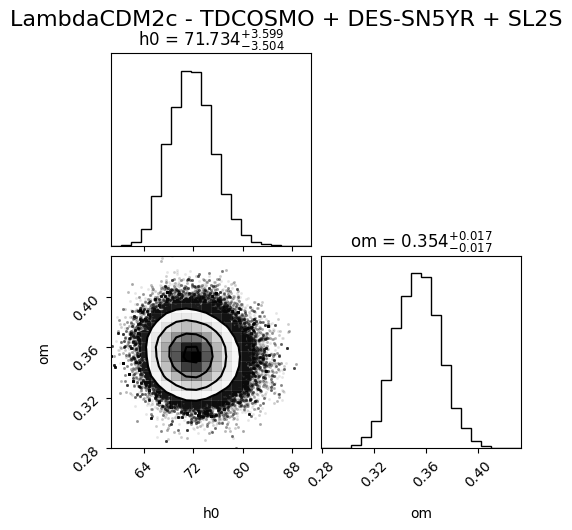

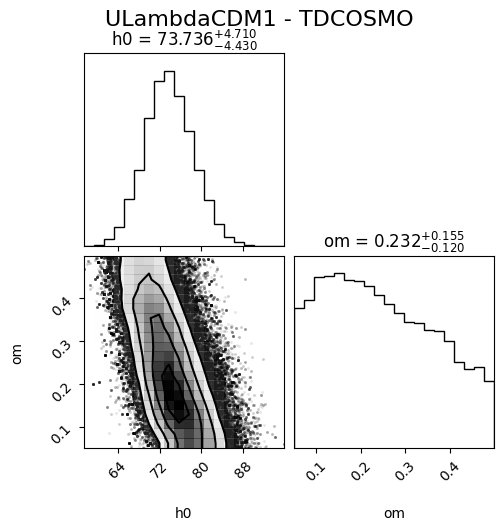

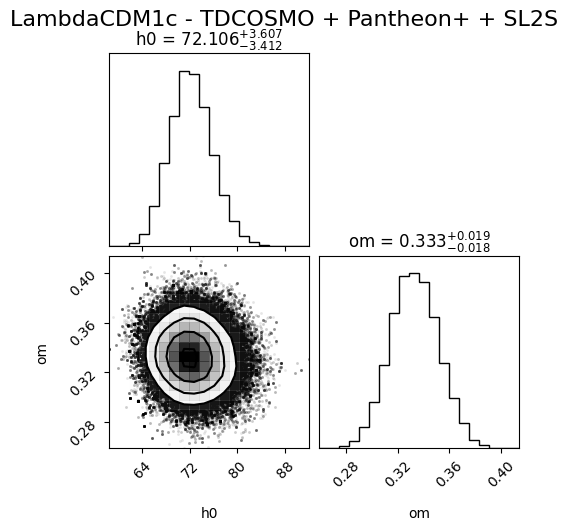

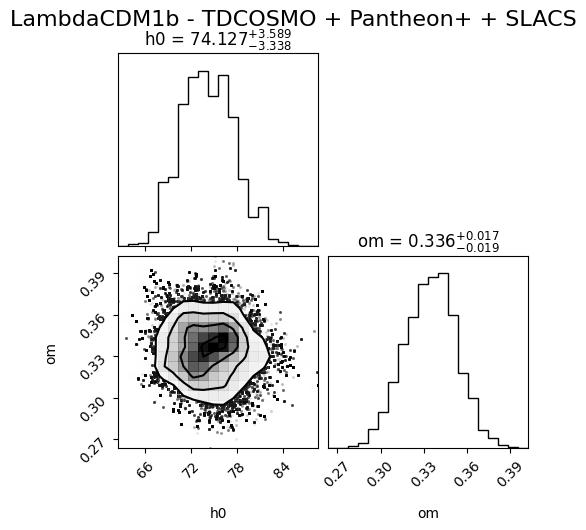

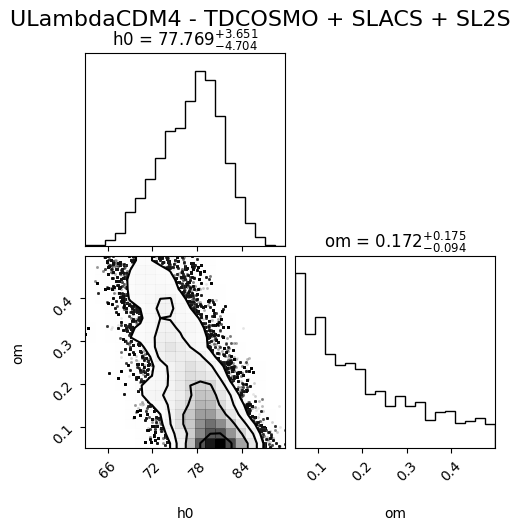

In [ ]:
cosmological_parameters = ['h0', 'om', 'w0', 'wa', 'w', 'ok']

for i, fil in enumerate(chain_files):
    with h5py.File(fil, "r") as f:
        samples = f["samples"][:]          # MCMC samples
        parameters = [p.decode() for p in f["parameters"][:]]  # parameter names
        description = f.attrs["description"]
        model_id = f.attrs["ModelID"]
        dataset_name = f.attrs["dataset"]

    # Indices of cosmological parameters that exist in this file
    cosmo_indices = [parameters.index(p) for p in cosmological_parameters if p in parameters]
    cosmo_names = [parameters[j] for j in cosmo_indices]

    # Extract corresponding samples
    cosmo_samples = samples[:, cosmo_indices]

    if i == 0:
        print("Parameters:", parameters)
        print("Description:", description)
        print('Sample shape:', samples.shape)
        print(f"Model: {model_id}")
        print(f"Dataset: {dataset_name}")

    fig = corner.corner(cosmo_samples, labels=cosmo_names, show_titles=True, title_fmt=".3f", title_kwargs={"fontsize": 12}, bins=20, smooth=0.8) 
    fig.suptitle(fr"{model_id} - {dataset_name}", fontsize=16)
    plt.subplots_adjust(top=0.9)
    plt.show()